# PyTorch para Deep Learning: Guia Completa

## Introducción

**PyTorch** es el framework de Deep Learning más utilizado en investigación y cada vez más en producción. Este notebook se centra específicamente en los conceptos y herramientas necesarios para **construir, entrenar y desplegar redes neuronales**.

### Objetivos

Al finalizar este notebook, serás capaz de:

1. Entender cómo PyTorch representa y procesa datos para Deep Learning
2. Comprender el mecanismo de **autograd** (diferenciación automática)
3. Construir **arquitecturas de redes neuronales** de cualquier complejidad
4. Implementar el **ciclo de entrenamiento** completo
5. Aplicar técnicas de **regularización** y **optimización**
6. Trabajar con diferentes tipos de capas: **Dense, Conv, RNN, Attention**

### Contenido

1. [Tensores para Deep Learning](#1.-Tensores-para-Deep-Learning)
2. [Autograd: El Motor del Aprendizaje](#2.-Autograd:-El-Motor-del-Aprendizaje)
3. [Construcción de Redes Neuronales](#3.-Construcción-de-Redes-Neuronales)
4. [Capas y Arquitecturas](#4.-Capas-y-Arquitecturas)
5. [Funciones de Pérdida](#5.-Funciones-de-Pérdida)
6. [Optimizadores y Learning Rate](#6.-Optimizadores-y-Learning-Rate)
7. [Regularización](#7.-Regularización)
8. [Gestión de Datos](#8.-Gestión-de-Datos)
9. [Ciclo de Entrenamiento Completo](#9.-Ciclo-de-Entrenamiento-Completo)
10. [Guardar y Cargar Modelos](#10.-Guardar-y-Cargar-Modelos)

---

In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, TensorDataset, random_split
import numpy as np
import matplotlib.pyplot as plt

# Configuración
print(f"PyTorch versión: {torch.__version__}")
print(f"CUDA disponible: {torch.cuda.is_available()}")

# Dispositivo para entrenamiento
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Dispositivo: {DEVICE}")

# Semilla para reproducibilidad
torch.manual_seed(42)
if torch.cuda.is_available():
    torch.cuda.manual_seed(42)

PyTorch versión: 2.9.1+cpu
CUDA disponible: False
Dispositivo: cpu


---

## 1. Tensores para Deep Learning

En Deep Learning, los **tensores** son la estructura fundamental que representa:
- **Datos de entrada**: imágenes, texto, audio, series temporales
- **Parámetros del modelo**: pesos y biases de las capas
- **Activaciones**: salidas intermedias de las capas
- **Gradientes**: derivadas para actualizar parámetros

### Convenciones de Dimensiones

| Tipo de Dato | Formato | Ejemplo |
|--------------|---------|----------|
| Datos tabulares | `(batch, features)` | `(64, 128)` |
| Imágenes | `(batch, channels, height, width)` | `(32, 3, 224, 224)` |
| Secuencias | `(batch, seq_len, features)` | `(16, 100, 512)` |
| Video | `(batch, time, channels, height, width)` | `(8, 30, 3, 224, 224)` |

**La primera dimensión siempre es el batch_size** (número de muestras procesadas en paralelo).

In [45]:
print("="*70)
print("TENSORES EN DEEP LEARNING")
print("="*70)

# =====================================================================
# Creación de tensores - Los métodos más usados en DL
# =====================================================================

# 1. torch.randn() - Inicialización de pesos (distribución normal)
weights = torch.randn(256, 128)  # Pesos de una capa linear
print(weights)
print(f"Pesos (256x128): media={weights.mean():.4f}, std={weights.std():.4f}")

# 2. torch.zeros() - Inicialización de biases
bias = torch.zeros(256)
print(bias)
print(f"Bias (256,): {bias[:5]}...")

# 3. torch.empty() + inicialización - Más control
w = torch.empty(256, 128)
nn.init.xavier_uniform_(w)  # Inicialización Xavier
print(f"Xavier init: media={w.mean():.4f}, std={w.std():.4f}")

TENSORES EN DEEP LEARNING
tensor([[-0.2593, -1.3505,  1.4444,  ...,  2.0331, -0.6997, -2.3405],
        [ 0.3827,  1.0990,  0.2209,  ..., -1.5483, -0.6401,  0.8956],
        [-0.7113, -2.2680,  0.6347,  ..., -0.5882,  0.4969,  0.5016],
        ...,
        [-0.0296, -0.7172,  1.2501,  ...,  0.2660, -1.6718, -1.6518],
        [-1.9553,  0.3290,  0.0719,  ..., -1.7753, -1.0259, -0.0758],
        [-0.4060,  0.0371,  0.4542,  ...,  1.8045,  0.9695,  0.5958]])
Pesos (256x128): media=-0.0011, std=1.0062
tensor([0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0

In [3]:
# =====================================================================
# Atributos críticos para Deep Learning
# =====================================================================

print("\nATRIBUTOS CRÍTICOS DE TENSORES")
print("-" * 50)

t = torch.randn(32, 3, 224, 224, requires_grad=True)

print(f".shape:         {t.shape}  <- Dimensiones del tensor")
print(f".dtype:         {t.dtype}  <- float32 es el estándar en DL")
print(f".device:        {t.device}  <- CPU o CUDA")
print(f".requires_grad: {t.requires_grad}  <- ¿Calcular gradientes?")
print(f".grad:          {t.grad}  <- Gradientes (None hasta backward)")


ATRIBUTOS CRÍTICOS DE TENSORES
--------------------------------------------------
.shape:         torch.Size([32, 3, 224, 224])  <- Dimensiones del tensor
.dtype:         torch.float32  <- float32 es el estándar en DL
.device:        cpu  <- CPU o CUDA
.requires_grad: True  <- ¿Calcular gradientes?
.grad:          None  <- Gradientes (None hasta backward)


In [4]:
# =====================================================================
# Movimiento CPU <-> GPU
# =====================================================================

print("\nMOVIMIENTO ENTRE DISPOSITIVOS")
print("-" * 50)

# Crear en CPU
t_cpu = torch.randn(1000, 1000)
print(f"Tensor en CPU: {t_cpu.device}")

# Mover a GPU (si está disponible)
t_device = t_cpu.to(DEVICE)
print(f"Tensor en {DEVICE}: {t_device.device}")

# Crear directamente en el dispositivo correcto
t_direct = torch.randn(1000, 1000, device=DEVICE)
print(f"Creado en {DEVICE}: {t_direct.device}")

# IMPORTANTE: Operaciones requieren tensores en el mismo dispositivo
# t_cpu + t_device  # ¡ERROR si t_device está en GPU!


MOVIMIENTO ENTRE DISPOSITIVOS
--------------------------------------------------
Tensor en CPU: cpu
Tensor en cpu: cpu
Creado en cpu: cpu


In [5]:
# =====================================================================
# Operaciones de forma esenciales en DL
# =====================================================================

print("\nOPERACIONES DE FORMA ESENCIALES")
print("-" * 50)

# Simular batch de imágenes: (batch, channels, height, width)
images = torch.randn(32, 3, 64, 64)
print(f"Imágenes originales: {images.shape}")

# 1. flatten() - Antes de capas fully connected
flat = images.flatten(start_dim=1)  # Mantener batch, aplanar el resto
print(f"Después de flatten(1): {flat.shape}  (3*64*64 = 12288)")

# 2. view() / reshape() - Reorganizar dimensiones
reshaped = flat.view(32, 3, 64, 64)  # Volver a la forma original
print(f"Después de view: {reshaped.shape}")

# 3. permute() - Cambiar orden de dimensiones (ej: NHWC <-> NCHW)
# PIL/numpy usan (H, W, C), PyTorch usa (C, H, W)
img_numpy_format = images.permute(0, 2, 3, 1)  # NCHW -> NHWC
print(f"NCHW -> NHWC: {images.shape} -> {img_numpy_format.shape}")

# 4. unsqueeze() / squeeze() - Añadir/quitar dimensiones
single_img = torch.randn(3, 64, 64)  # Una sola imagen
batched = single_img.unsqueeze(0)     # Añadir dimensión batch
print(f"unsqueeze(0): {single_img.shape} -> {batched.shape}")


OPERACIONES DE FORMA ESENCIALES
--------------------------------------------------
Imágenes originales: torch.Size([32, 3, 64, 64])
Después de flatten(1): torch.Size([32, 12288])  (3*64*64 = 12288)
Después de view: torch.Size([32, 3, 64, 64])
NCHW -> NHWC: torch.Size([32, 3, 64, 64]) -> torch.Size([32, 64, 64, 3])
unsqueeze(0): torch.Size([3, 64, 64]) -> torch.Size([1, 3, 64, 64])


---

## 2. Autograd: El Motor del Aprendizaje

**Autograd** es el sistema de diferenciación automática de PyTorch. Es lo que hace posible el **backpropagation** sin tener que calcular derivadas manualmente.

### Cómo Funciona

1. **Forward Pass**: PyTorch construye un **grafo computacional** dinámico
2. **Backward Pass**: Recorre el grafo en reversa calculando gradientes
3. **Actualización**: Los gradientes se usan para actualizar parámetros

```
Input (x) --> Capa 1 --> Capa 2 --> ... --> Output --> Loss
                                                         |
                                                    backward()
                                                         |
                                                         v
Gradientes <-- dL/dW1 <-- dL/dW2 <-- ... <-- dL/dOutput
```

In [6]:
print("="*70)
print("AUTOGRAD: DIFERENCIACIÓN AUTOMÁTICA")
print("="*70)

# =====================================================================
# Ejemplo básico: Regresión lineal manual
# =====================================================================

# Datos de ejemplo
X = torch.tensor([[1.0], [2.0], [3.0], [4.0]])
y = torch.tensor([[2.0], [4.0], [6.0], [8.0]])  # y = 2x

# Parámetros con requires_grad=True para calcular gradientes
w = torch.tensor([[1.0]], requires_grad=True)  # Peso inicial
b = torch.tensor([[0.0]], requires_grad=True)  # Bias inicial

print("Regresión lineal: y = w*x + b")
print(f"Parámetros iniciales: w={w.item():.2f}, b={b.item():.2f}")
print()

# Forward pass
y_pred = X @ w + b  # Predicción: y = Xw + b
loss = ((y_pred - y) ** 2).mean()  # MSE Loss

print(f"Forward pass:")
print(f"  Predicciones: {y_pred.detach().T}")
print(f"  Loss (MSE): {loss.item():.4f}")

AUTOGRAD: DIFERENCIACIÓN AUTOMÁTICA
Regresión lineal: y = w*x + b
Parámetros iniciales: w=1.00, b=0.00

Forward pass:
  Predicciones: tensor([[1., 2., 3., 4.]])
  Loss (MSE): 7.5000


In [7]:
# Backward pass - Calcula gradientes
loss.backward()

print(f"\nBackward pass:")
print(f"  w.grad = dL/dw = {w.grad.item():.4f}")
print(f"  b.grad = dL/db = {b.grad.item():.4f}")

# Los gradientes nos dicen cómo ajustar los parámetros:
# - Gradiente negativo -> aumentar el parámetro reduce el loss
# - Gradiente positivo -> disminuir el parámetro reduce el loss


Backward pass:
  w.grad = dL/dw = -15.0000
  b.grad = dL/db = -5.0000


In [8]:
# =====================================================================
# Entrenamiento manual con gradientes
# =====================================================================

print("\nENTRENAMIENTO MANUAL")
print("-" * 50)

# Reiniciar parámetros
w = torch.tensor([[1.0]], requires_grad=True)
b = torch.tensor([[0.0]], requires_grad=True)
lr = 0.1  # Learning rate

for epoch in range(100):
    # Forward
    y_pred = X @ w + b
    loss = ((y_pred - y) ** 2).mean()
    
    # Backward
    loss.backward()
    
    # Actualizar parámetros (sin tracking de gradientes)
    with torch.no_grad():
        w -= lr * w.grad
        b -= lr * b.grad
    
    # IMPORTANTE: Limpiar gradientes para la siguiente iteración
    w.grad.zero_()
    b.grad.zero_()
    
    if epoch % 20 == 0:
        print(f"Epoch {epoch:3d}: Loss={loss.item():.6f}, w={w.item():.4f}, b={b.item():.4f}")

print(f"\nResultado final: w={w.item():.4f} (esperado: 2), b={b.item():.4f} (esperado: 0)")


ENTRENAMIENTO MANUAL
--------------------------------------------------
Epoch   0: Loss=7.500000, w=2.5000, b=0.5000
Epoch  20: Loss=0.004602, w=1.9454, b=0.1611
Epoch  40: Loss=0.001364, w=1.9702, b=0.0877
Epoch  60: Loss=0.000404, w=1.9838, b=0.0477
Epoch  80: Loss=0.000120, w=1.9912, b=0.0260

Resultado final: w=1.9950 (esperado: 2), b=0.0146 (esperado: 0)


In [9]:
# =====================================================================
# Control de gradientes
# =====================================================================

print("\nCONTROL DE GRADIENTES")
print("-" * 50)

x = torch.randn(3, requires_grad=True)

# 1. torch.no_grad() - Desactivar cálculo de gradientes
# Usar durante: evaluación, inferencia, actualización manual de pesos
print("1. torch.no_grad():")
with torch.no_grad():
    y = x * 2
    print(f"   Dentro de no_grad: y.requires_grad = {y.requires_grad}")

# 2. tensor.detach() - Desconectar del grafo
print("\n2. tensor.detach():")
z = x.detach()  # Nueva referencia sin historial
print(f"   x.requires_grad = {x.requires_grad}")
print(f"   x.detach().requires_grad = {z.requires_grad}")

# 3. @torch.inference_mode() - Más eficiente que no_grad para inferencia
print("\n3. torch.inference_mode():")
with torch.inference_mode():
    y = x * 2
    print(f"   Más rápido que no_grad para inferencia")


CONTROL DE GRADIENTES
--------------------------------------------------
1. torch.no_grad():
   Dentro de no_grad: y.requires_grad = False

2. tensor.detach():
   x.requires_grad = True
   x.detach().requires_grad = False

3. torch.inference_mode():
   Más rápido que no_grad para inferencia


---

## 3. Construcción de Redes Neuronales

PyTorch ofrece dos formas principales de construir redes:

1. **`nn.Sequential`**: Para arquitecturas simples y lineales
2. **Subclase de `nn.Module`**: Para arquitecturas complejas con bifurcaciones

### Estructura de nn.Module

```python
class MiRed(nn.Module):
    def __init__(self):
        super().__init__()  # ¡Obligatorio!
        # Definir capas como atributos
        self.capa1 = nn.Linear(input, hidden)
        self.capa2 = nn.Linear(hidden, output)
    
    def forward(self, x):
        # Definir flujo de datos
        x = F.relu(self.capa1(x))
        x = self.capa2(x)
        return x
```

In [10]:
print("="*70)
print("CONSTRUCCIÓN DE REDES NEURONALES")
print("="*70)

# =====================================================================
# Método 1: nn.Sequential - Rápido y simple
# =====================================================================

print("\n1. nn.Sequential - Arquitectura lineal")
print("-" * 50)

# MLP simple para clasificación
mlp_sequential = nn.Sequential(
    nn.Linear(784, 512),      # Capa 1: 784 -> 512
    nn.ReLU(),                 # Activación
    nn.Dropout(0.2),           # Regularización
    nn.Linear(512, 256),       # Capa 2: 512 -> 256
    nn.ReLU(),
    nn.Dropout(0.2),
    nn.Linear(256, 10)         # Salida: 256 -> 10 clases
)

print(mlp_sequential)

# Forward pass automático
x = torch.randn(32, 784)  # Batch de 32
out = mlp_sequential(x)
print(f"\nInput: {x.shape} -> Output: {out.shape}")

CONSTRUCCIÓN DE REDES NEURONALES

1. nn.Sequential - Arquitectura lineal
--------------------------------------------------
Sequential(
  (0): Linear(in_features=784, out_features=512, bias=True)
  (1): ReLU()
  (2): Dropout(p=0.2, inplace=False)
  (3): Linear(in_features=512, out_features=256, bias=True)
  (4): ReLU()
  (5): Dropout(p=0.2, inplace=False)
  (6): Linear(in_features=256, out_features=10, bias=True)
)

Input: torch.Size([32, 784]) -> Output: torch.Size([32, 10])


In [11]:
# =====================================================================
# Método 2: Subclase de nn.Module - Máximo control
# =====================================================================

print("\n2. Subclase de nn.Module - Control total")
print("-" * 50)

class MLP(nn.Module):
    """
    Perceptrón Multicapa (MLP) para clasificación.
    
    Arquitectura: Input -> Hidden1 -> Hidden2 -> Output
    """
    
    def __init__(self, input_size, hidden_sizes, num_classes, dropout=0.2):
        """
        Args:
            input_size: Dimensión de entrada
            hidden_sizes: Lista con tamaños de capas ocultas
            num_classes: Número de clases de salida
            dropout: Probabilidad de dropout
        """
        super().__init__()  # ¡Siempre llamar al padre!
        
        # Construir capas dinámicamente
        layers = []
        prev_size = input_size
        
        for hidden_size in hidden_sizes:
            layers.extend([
                nn.Linear(prev_size, hidden_size),
                nn.BatchNorm1d(hidden_size),  # Normalización
                nn.ReLU(),
                nn.Dropout(dropout)
            ])
            prev_size = hidden_size
        
        self.hidden_layers = nn.Sequential(*layers)
        self.output_layer = nn.Linear(prev_size, num_classes)
    
    def forward(self, x):
        """
        Forward pass.
        
        Args:
            x: Tensor de entrada (batch_size, input_size)
        Returns:
            logits: Tensor de salida (batch_size, num_classes)
        """
        x = self.hidden_layers(x)
        logits = self.output_layer(x)
        return logits

# Crear modelo
model = MLP(
    input_size=784,
    hidden_sizes=[512, 256, 128],
    num_classes=10,
    dropout=0.3
)

print(model)

# Contar parámetros
total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"\nParámetros totales: {total_params:,}")
print(f"Parámetros entrenables: {trainable_params:,}")


2. Subclase de nn.Module - Control total
--------------------------------------------------
MLP(
  (hidden_layers): Sequential(
    (0): Linear(in_features=784, out_features=512, bias=True)
    (1): BatchNorm1d(512, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): Dropout(p=0.3, inplace=False)
    (4): Linear(in_features=512, out_features=256, bias=True)
    (5): BatchNorm1d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): ReLU()
    (7): Dropout(p=0.3, inplace=False)
    (8): Linear(in_features=256, out_features=128, bias=True)
    (9): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (10): ReLU()
    (11): Dropout(p=0.3, inplace=False)
  )
  (output_layer): Linear(in_features=128, out_features=10, bias=True)
)

Parámetros totales: 569,226
Parámetros entrenables: 569,226


In [12]:
# =====================================================================
# Arquitectura con conexiones residuales (Skip Connections)
# =====================================================================

print("\n3. Red con Skip Connections (estilo ResNet)")
print("-" * 50)

class ResidualBlock(nn.Module):
    """Bloque residual: output = F(x) + x"""
    
    def __init__(self, features):
        super().__init__()
        self.block = nn.Sequential(
            nn.Linear(features, features),
            nn.BatchNorm1d(features),
            nn.ReLU(),
            nn.Linear(features, features),
            nn.BatchNorm1d(features)
        )
        self.relu = nn.ReLU()
    
    def forward(self, x):
        residual = x           # Guardar entrada
        out = self.block(x)    # Transformación
        out = out + residual   # Skip connection
        out = self.relu(out)   # Activación final
        return out


class ResNet(nn.Module):
    """Red con bloques residuales."""
    
    def __init__(self, input_size, hidden_size, num_blocks, num_classes):
        super().__init__()
        
        # Capa de entrada
        self.input_layer = nn.Sequential(
            nn.Linear(input_size, hidden_size),
            nn.BatchNorm1d(hidden_size),
            nn.ReLU()
        )
        
        # Bloques residuales
        self.res_blocks = nn.Sequential(
            *[ResidualBlock(hidden_size) for _ in range(num_blocks)]
        )
        
        # Capa de salida
        self.output_layer = nn.Linear(hidden_size, num_classes)
    
    def forward(self, x):
        x = self.input_layer(x)
        x = self.res_blocks(x)
        x = self.output_layer(x)
        return x

resnet = ResNet(input_size=784, hidden_size=256, num_blocks=4, num_classes=10)
print(f"ResNet con 4 bloques residuales")
print(f"Parámetros: {sum(p.numel() for p in resnet.parameters()):,}")


3. Red con Skip Connections (estilo ResNet)
--------------------------------------------------
ResNet con 4 bloques residuales
Parámetros: 734,474


---

## 4. Capas y Arquitecturas

PyTorch proporciona capas para diferentes tipos de arquitecturas:

| Tipo | Capas | Uso |
|------|-------|-----|
| **Fully Connected** | `nn.Linear` | Datos tabulares, clasificación |
| **Convolucionales** | `nn.Conv1d/2d/3d` | Imágenes, audio, video |
| **Recurrentes** | `nn.RNN, nn.LSTM, nn.GRU` | Secuencias, texto |
| **Atención** | `nn.MultiheadAttention` | Transformers, NLP moderno |

In [13]:
print("="*70)
print("CAPAS FUNDAMENTALES")
print("="*70)

# =====================================================================
# nn.Linear - Capa Fully Connected
# =====================================================================

print("\n1. nn.Linear(in_features, out_features)")
print("-" * 50)
print("Operación: y = x @ W.T + b")
print("Uso: Capas densas, clasificador final")

linear = nn.Linear(in_features=512, out_features=256)

print(f"\nForma de pesos: {linear.weight.shape}  (out, in)")
print(f"Forma de bias:  {linear.bias.shape}")
print(f"Parámetros: {512*256 + 256} = {linear.weight.numel() + linear.bias.numel()}")

x = torch.randn(32, 512)
out = linear(x)
print(f"\nEjemplo: {x.shape} -> {out.shape}")

CAPAS FUNDAMENTALES

1. nn.Linear(in_features, out_features)
--------------------------------------------------
Operación: y = x @ W.T + b
Uso: Capas densas, clasificador final

Forma de pesos: torch.Size([256, 512])  (out, in)
Forma de bias:  torch.Size([256])
Parámetros: 131328 = 131328

Ejemplo: torch.Size([32, 512]) -> torch.Size([32, 256])


In [14]:
# =====================================================================
# nn.Conv2d - Convolución 2D (para imágenes)
# =====================================================================

print("\n2. nn.Conv2d(in_channels, out_channels, kernel_size, stride, padding)")
print("-" * 50)
print("Operación: Aplica filtros convolucionales")
print("Uso: Extracción de características en imágenes")

conv = nn.Conv2d(
    in_channels=3,       # RGB
    out_channels=64,     # 64 filtros
    kernel_size=3,       # Filtros 3x3
    stride=1,            # Paso 1
    padding=1            # Padding para mantener tamaño
)

print(f"\nForma de filtros: {conv.weight.shape}  (out_ch, in_ch, kH, kW)")
print(f"Parámetros: {conv.weight.numel() + conv.bias.numel()}")

# Fórmula de tamaño de salida:
# H_out = (H_in + 2*padding - kernel_size) / stride + 1

img = torch.randn(32, 3, 224, 224)  # Batch de imágenes
out = conv(img)
print(f"\nEjemplo: {img.shape} -> {out.shape}")
print(f"Con padding=1, stride=1: tamaño espacial se mantiene")


2. nn.Conv2d(in_channels, out_channels, kernel_size, stride, padding)
--------------------------------------------------
Operación: Aplica filtros convolucionales
Uso: Extracción de características en imágenes

Forma de filtros: torch.Size([64, 3, 3, 3])  (out_ch, in_ch, kH, kW)
Parámetros: 1792

Ejemplo: torch.Size([32, 3, 224, 224]) -> torch.Size([32, 64, 224, 224])
Con padding=1, stride=1: tamaño espacial se mantiene


In [15]:
# =====================================================================
# Pooling - Reducción de dimensionalidad espacial
# =====================================================================

print("\n3. Capas de Pooling")
print("-" * 50)

# MaxPool2d - Toma el máximo de cada región
maxpool = nn.MaxPool2d(kernel_size=2, stride=2)

# AvgPool2d - Toma el promedio de cada región
avgpool = nn.AvgPool2d(kernel_size=2, stride=2)

# AdaptiveAvgPool2d - Salida de tamaño fijo (muy útil)
adaptive = nn.AdaptiveAvgPool2d(output_size=(1, 1))  # Global Average Pooling

x = torch.randn(32, 64, 56, 56)
print(f"Input: {x.shape}")
print(f"MaxPool2d(2,2): {maxpool(x).shape}")
print(f"AvgPool2d(2,2): {avgpool(x).shape}")
print(f"AdaptiveAvgPool2d(1,1): {adaptive(x).shape}  <- Global Average Pooling")


3. Capas de Pooling
--------------------------------------------------
Input: torch.Size([32, 64, 56, 56])
MaxPool2d(2,2): torch.Size([32, 64, 28, 28])
AvgPool2d(2,2): torch.Size([32, 64, 28, 28])
AdaptiveAvgPool2d(1,1): torch.Size([32, 64, 1, 1])  <- Global Average Pooling


In [16]:
# =====================================================================
# CNN Completa (Ejemplo: mini VGG)
# =====================================================================

print("\n4. CNN Completa (estilo VGG)")
print("-" * 50)

class SimpleCNN(nn.Module):
    """CNN simple para clasificación de imágenes."""
    
    def __init__(self, num_classes=10):
        super().__init__()
        
        # Bloque convolucional 1
        self.conv_block1 = nn.Sequential(
            nn.Conv2d(3, 32, 3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.Conv2d(32, 32, 3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(2, 2)  # 32x32 -> 16x16
        )
        
        # Bloque convolucional 2
        self.conv_block2 = nn.Sequential(
            nn.Conv2d(32, 64, 3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.Conv2d(64, 64, 3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(2, 2)  # 16x16 -> 8x8
        )
        
        # Global Average Pooling + Clasificador
        self.classifier = nn.Sequential(
            nn.AdaptiveAvgPool2d(1),  # (N, 64, 8, 8) -> (N, 64, 1, 1)
            nn.Flatten(),              # (N, 64, 1, 1) -> (N, 64)
            nn.Linear(64, num_classes)
        )
    
    def forward(self, x):
        x = self.conv_block1(x)
        x = self.conv_block2(x)
        x = self.classifier(x)
        return x

cnn = SimpleCNN(num_classes=10)
print(f"Parámetros: {sum(p.numel() for p in cnn.parameters()):,}")

# Test forward pass
x = torch.randn(4, 3, 32, 32)  # 4 imágenes de 32x32
out = cnn(x)
print(f"\nForward: {x.shape} -> {out.shape}")


4. CNN Completa (estilo VGG)
--------------------------------------------------
Parámetros: 66,602

Forward: torch.Size([4, 3, 32, 32]) -> torch.Size([4, 10])


In [17]:
# =====================================================================
# nn.LSTM - Para secuencias
# =====================================================================

print("\n5. nn.LSTM - Redes Recurrentes")
print("-" * 50)
print("Uso: Texto, series temporales, audio")

lstm = nn.LSTM(
    input_size=128,      # Features por timestep
    hidden_size=256,     # Dimensión del estado oculto
    num_layers=2,        # Capas apiladas
    batch_first=True,    # Input: (batch, seq, features)
    dropout=0.2,         # Dropout entre capas
    bidirectional=True   # Procesar en ambas direcciones
)

# Input: (batch, seq_len, input_size)
seq = torch.randn(32, 100, 128)  # 32 secuencias de 100 timesteps

# Output: output, (h_n, c_n)
# output: (batch, seq_len, hidden_size * num_directions)
# h_n: (num_layers * num_directions, batch, hidden_size)
output, (h_n, c_n) = lstm(seq)

print(f"\nInput: {seq.shape}")
print(f"Output: {output.shape}  (256*2=512 por bidireccional)")
print(f"Hidden state: {h_n.shape}  (2 capas * 2 direcciones)")


5. nn.LSTM - Redes Recurrentes
--------------------------------------------------
Uso: Texto, series temporales, audio

Input: torch.Size([32, 100, 128])
Output: torch.Size([32, 100, 512])  (256*2=512 por bidireccional)
Hidden state: torch.Size([4, 32, 256])  (2 capas * 2 direcciones)


In [18]:
# =====================================================================
# nn.MultiheadAttention - Mecanismo de atención
# =====================================================================

print("\n6. nn.MultiheadAttention - Transformers")
print("-" * 50)
print("Uso: NLP moderno, Vision Transformers")

attn = nn.MultiheadAttention(
    embed_dim=512,      # Dimensión de embeddings
    num_heads=8,        # Número de cabezas
    dropout=0.1,
    batch_first=True
)

# Self-attention: query = key = value
x = torch.randn(32, 100, 512)  # 32 secuencias de 100 tokens, dim 512

# attn_output: resultado de atención
# attn_weights: pesos de atención (qué tokens atienden a cuáles)
attn_output, attn_weights = attn(x, x, x)

print(f"\nInput: {x.shape}")
print(f"Output: {attn_output.shape}")
print(f"Attention weights: {attn_weights.shape}  (cada token atiende a todos)")


6. nn.MultiheadAttention - Transformers
--------------------------------------------------
Uso: NLP moderno, Vision Transformers

Input: torch.Size([32, 100, 512])
Output: torch.Size([32, 100, 512])
Attention weights: torch.Size([32, 100, 100])  (cada token atiende a todos)



7. Funciones de Activación
--------------------------------------------------


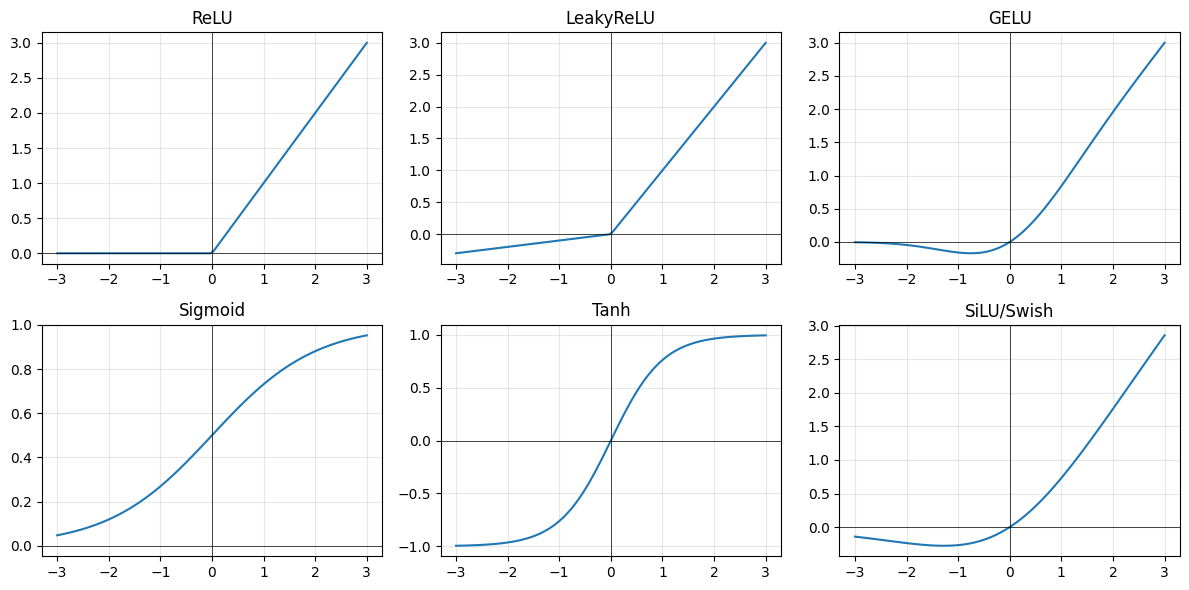


Recomendaciones:
  - ReLU: Default para capas ocultas
  - GELU: Transformers, modelos modernos
  - SiLU: ResNets modernos, EfficientNet
  - Sigmoid: Salida para clasificación binaria
  - Softmax: Salida para clasificación multiclase


In [19]:
# =====================================================================
# Funciones de Activación
# =====================================================================

print("\n7. Funciones de Activación")
print("-" * 50)

x = torch.linspace(-3, 3, 100)

activations = {
    'ReLU': F.relu,
    'LeakyReLU': lambda x: F.leaky_relu(x, 0.1),
    'GELU': F.gelu,
    'Sigmoid': torch.sigmoid,
    'Tanh': torch.tanh,
    'SiLU/Swish': F.silu
}

fig, axes = plt.subplots(2, 3, figsize=(12, 6))
for ax, (name, func) in zip(axes.flat, activations.items()):
    y = func(x)
    ax.plot(x.numpy(), y.detach().numpy())
    ax.set_title(name)
    ax.axhline(0, color='k', linewidth=0.5)
    ax.axvline(0, color='k', linewidth=0.5)
    ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print("\nRecomendaciones:")
print("  - ReLU: Default para capas ocultas")
print("  - GELU: Transformers, modelos modernos")
print("  - SiLU: ResNets modernos, EfficientNet")
print("  - Sigmoid: Salida para clasificación binaria")
print("  - Softmax: Salida para clasificación multiclase")

---

## 5. Funciones de Pérdida

La función de pérdida (loss) mide qué tan lejos están las predicciones del modelo de los valores reales. Es lo que el optimizador intenta minimizar.

In [20]:
print("="*70)
print("FUNCIONES DE PÉRDIDA")
print("="*70)

# =====================================================================
# Regresión
# =====================================================================

print("\n1. REGRESIÓN")
print("-" * 50)

pred = torch.tensor([2.5, 0.0, 2.1, 1.5])
target = torch.tensor([3.0, -0.5, 2.0, 1.0])

# MSE Loss - Penaliza errores grandes más
mse = nn.MSELoss()
print(f"MSELoss: {mse(pred, target):.4f}")
print(f"  Fórmula: mean((pred - target)^2)")

# L1 Loss (MAE) - Más robusto a outliers
l1 = nn.L1Loss()
print(f"\nL1Loss (MAE): {l1(pred, target):.4f}")
print(f"  Fórmula: mean(|pred - target|)")

# Huber Loss - Combina MSE y L1
huber = nn.HuberLoss(delta=1.0)
print(f"\nHuberLoss: {huber(pred, target):.4f}")
print(f"  Combina MSE (errores pequeños) y L1 (errores grandes)")

FUNCIONES DE PÉRDIDA

1. REGRESIÓN
--------------------------------------------------
MSELoss: 0.1900
  Fórmula: mean((pred - target)^2)

L1Loss (MAE): 0.4000
  Fórmula: mean(|pred - target|)

HuberLoss: 0.0950
  Combina MSE (errores pequeños) y L1 (errores grandes)


In [21]:
# =====================================================================
# Clasificación
# =====================================================================

print("\n2. CLASIFICACIÓN")
print("-" * 50)

# Clasificación multiclase
logits = torch.tensor([[2.0, 1.0, 0.1],   # Predicción: clase 0
                       [0.5, 2.5, 0.3],   # Predicción: clase 1
                       [0.1, 0.2, 2.0]])  # Predicción: clase 2
targets = torch.tensor([0, 1, 2])  # Etiquetas correctas

# CrossEntropyLoss - El estándar para clasificación
# NOTA: Aplica softmax internamente, NO aplicar softmax antes
ce_loss = nn.CrossEntropyLoss()
print(f"CrossEntropyLoss: {ce_loss(logits, targets):.4f}")
print(f"  Input: logits (sin softmax)")
print(f"  Target: índices de clase (no one-hot)")

# Clasificación binaria
logits_bin = torch.tensor([0.8, -0.5, 1.2, -1.0])
targets_bin = torch.tensor([1.0, 0.0, 1.0, 0.0])

# BCEWithLogitsLoss - Binario con sigmoid interno
bce_logits = nn.BCEWithLogitsLoss()
print(f"\nBCEWithLogitsLoss: {bce_logits(logits_bin, targets_bin):.4f}")
print(f"  Input: logits (sin sigmoid)")
print(f"  Target: 0 o 1")


2. CLASIFICACIÓN
--------------------------------------------------
CrossEntropyLoss: 0.3036
  Input: logits (sin softmax)
  Target: índices de clase (no one-hot)

BCEWithLogitsLoss: 0.3554
  Input: logits (sin sigmoid)
  Target: 0 o 1


In [22]:
# =====================================================================
# Clases desbalanceadas
# =====================================================================

print("\n3. CLASES DESBALANCEADAS")
print("-" * 50)

# Pesos por clase (inverso de frecuencia)
# Si clase 0 tiene 1000 muestras y clase 1 tiene 100,
# dar peso 0.1 a clase 0 y peso 1.0 a clase 1
class_weights = torch.tensor([0.1, 1.0, 0.5])  # 3 clases

weighted_ce = nn.CrossEntropyLoss(weight=class_weights)
print(f"CrossEntropyLoss con pesos: {weighted_ce(logits, targets):.4f}")

# Focal Loss (para detección de objetos con muchos negativos)
# No está en PyTorch estándar, pero es fácil implementar:
def focal_loss(pred, target, gamma=2.0, alpha=0.25):
    ce = F.cross_entropy(pred, target, reduction='none')
    pt = torch.exp(-ce)  # Probabilidad de la clase correcta
    focal = alpha * (1 - pt) ** gamma * ce
    return focal.mean()

print(f"Focal Loss (gamma=2): {focal_loss(logits, targets):.4f}")
print(f"  Reduce el peso de ejemplos fáciles, enfoca en difíciles")


3. CLASES DESBALANCEADAS
--------------------------------------------------
CrossEntropyLoss con pesos: 0.2491
Focal Loss (gamma=2): 0.0061
  Reduce el peso de ejemplos fáciles, enfoca en difíciles


---

## 6. Optimizadores y Learning Rate

Los optimizadores actualizan los parámetros del modelo usando los gradientes calculados.

In [23]:
print("="*70)
print("OPTIMIZADORES")
print("="*70)

# Modelo de ejemplo
model = nn.Sequential(
    nn.Linear(784, 256),
    nn.ReLU(),
    nn.Linear(256, 10)
)

print("\nOptimizadores principales:")
print("-" * 50)

# SGD - Simple pero efectivo con momentum
sgd = optim.SGD(model.parameters(), lr=0.01, momentum=0.9, weight_decay=1e-4)
print("SGD(lr=0.01, momentum=0.9)")
print("  + Simple y bien entendido")
print("  + Funciona bien para CNNs")
print("  - Requiere tuning de learning rate")

# Adam - El más usado, buen default
adam = optim.Adam(model.parameters(), lr=0.001, betas=(0.9, 0.999))
print("\nAdam(lr=0.001)")
print("  + Adaptativo, buen default")
print("  + Converge rápido")
print("  - Puede no generalizar tan bien como SGD")

# AdamW - Adam con weight decay correcto
adamw = optim.AdamW(model.parameters(), lr=0.001, weight_decay=0.01)
print("\nAdamW(lr=0.001, weight_decay=0.01)")
print("  + Regularización L2 correcta")
print("  + Recomendado para Transformers")
print("  + El estándar actual")

OPTIMIZADORES

Optimizadores principales:
--------------------------------------------------
SGD(lr=0.01, momentum=0.9)
  + Simple y bien entendido
  + Funciona bien para CNNs
  - Requiere tuning de learning rate

Adam(lr=0.001)
  + Adaptativo, buen default
  + Converge rápido
  - Puede no generalizar tan bien como SGD

AdamW(lr=0.001, weight_decay=0.01)
  + Regularización L2 correcta
  + Recomendado para Transformers
  + El estándar actual


In [24]:
# =====================================================================
# Learning Rate Schedulers
# =====================================================================

print("\nLEARNING RATE SCHEDULERS")
print("-" * 50)

optimizer = optim.Adam(model.parameters(), lr=0.001)

# StepLR - Reduce LR cada N épocas
step_scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=10, gamma=0.1)
print("StepLR(step_size=10, gamma=0.1)")
print("  LR se multiplica por 0.1 cada 10 épocas")

# CosineAnnealingLR - Decaimiento suave
cosine_scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=100)
print("\nCosineAnnealingLR(T_max=100)")
print("  Decaimiento coseno hasta época 100")

# OneCycleLR - Ciclo completo (warmup + decay)
onecycle = optim.lr_scheduler.OneCycleLR(
    optimizer, 
    max_lr=0.01,
    total_steps=1000,
    pct_start=0.3  # 30% warmup
)
print("\nOneCycleLR(max_lr=0.01)")
print("  Warmup -> Max -> Decay en un ciclo")
print("  Recomendado para entrenamientos cortos")


LEARNING RATE SCHEDULERS
--------------------------------------------------
StepLR(step_size=10, gamma=0.1)
  LR se multiplica por 0.1 cada 10 épocas

CosineAnnealingLR(T_max=100)
  Decaimiento coseno hasta época 100

OneCycleLR(max_lr=0.01)
  Warmup -> Max -> Decay en un ciclo
  Recomendado para entrenamientos cortos


c:\Users\XaviLara\AppData\Local\Programs\Python\Python312\Lib\site-packages\torch\optim\lr_scheduler.py:192: UserWarning: Detected call of `lr_scheduler.step()` before `optimizer.step()`. In PyTorch 1.1.0 and later, you should call them in the opposite order: `optimizer.step()` before `lr_scheduler.step()`.  Failure to do this will result in PyTorch skipping the first value of the learning rate schedule. See more details at https://pytorch.org/docs/stable/optim.html#how-to-adjust-learning-rate
  warnings.warn(


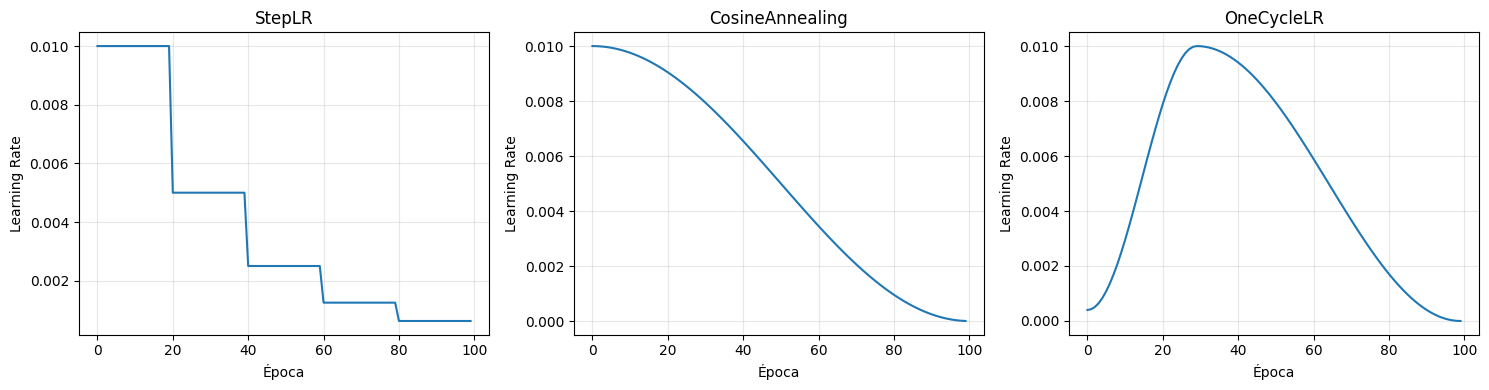

In [25]:
# Visualizar schedulers
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, (name, sched_fn) in zip(axes, [
    ('StepLR', lambda opt: optim.lr_scheduler.StepLR(opt, step_size=20, gamma=0.5)),
    ('CosineAnnealing', lambda opt: optim.lr_scheduler.CosineAnnealingLR(opt, T_max=100)),
    ('OneCycleLR', lambda opt: optim.lr_scheduler.OneCycleLR(opt, max_lr=0.01, total_steps=100))
]):
    model_temp = nn.Linear(10, 10)
    opt = optim.Adam(model_temp.parameters(), lr=0.01)
    scheduler = sched_fn(opt)
    
    lrs = []
    for _ in range(100):
        lrs.append(opt.param_groups[0]['lr'])
        scheduler.step()
    
    ax.plot(lrs)
    ax.set_title(name)
    ax.set_xlabel('Época')
    ax.set_ylabel('Learning Rate')
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

---

## 7. Regularización

Técnicas para prevenir overfitting y mejorar la generalización del modelo.

In [26]:
print("="*70)
print("TÉCNICAS DE REGULARIZACIÓN")
print("="*70)

# =====================================================================
# 1. Dropout
# =====================================================================

print("\n1. Dropout")
print("-" * 50)

dropout = nn.Dropout(p=0.5)  # 50% de neuronas a 0
x = torch.ones(1, 10)

print(f"Input: {x}")

dropout.train()  # Modo entrenamiento: dropout activo
print(f"Train mode: {dropout(x)}")
print(f"  Nota: valores no-cero escalados por 1/(1-p) = 2")

dropout.eval()   # Modo evaluación: dropout desactivado
print(f"Eval mode:  {dropout(x)}")

print("\nVariantes:")
print("  nn.Dropout(p)      - Standard")
print("  nn.Dropout2d(p)    - Para CNNs (canales completos)")
print("  nn.AlphaDropout(p) - Para SELU activation")

TÉCNICAS DE REGULARIZACIÓN

1. Dropout
--------------------------------------------------
Input: tensor([[1., 1., 1., 1., 1., 1., 1., 1., 1., 1.]])
Train mode: tensor([[2., 2., 2., 2., 0., 0., 2., 0., 2., 2.]])
  Nota: valores no-cero escalados por 1/(1-p) = 2
Eval mode:  tensor([[1., 1., 1., 1., 1., 1., 1., 1., 1., 1.]])

Variantes:
  nn.Dropout(p)      - Standard
  nn.Dropout2d(p)    - Para CNNs (canales completos)
  nn.AlphaDropout(p) - Para SELU activation


In [27]:
# =====================================================================
# 2. Batch Normalization
# =====================================================================

print("\n2. Batch Normalization")
print("-" * 50)

# BatchNorm normaliza cada feature a media=0, std=1
# Luego aplica transformación aprendida: gamma*x + beta

bn1d = nn.BatchNorm1d(num_features=64)   # Para (batch, features)
bn2d = nn.BatchNorm2d(num_features=64)   # Para (batch, channels, H, W)

print(f"BatchNorm1d(64): {bn1d.weight.shape} gamma, {bn1d.bias.shape} beta")
print(f"BatchNorm2d(64): Para imágenes con 64 canales")

# LayerNorm - Normaliza sobre features (no batch)
# Preferido para Transformers
ln = nn.LayerNorm(normalized_shape=512)
print(f"\nLayerNorm(512): Normaliza sobre la última dimensión")
print(f"  Usado en Transformers")


2. Batch Normalization
--------------------------------------------------
BatchNorm1d(64): torch.Size([64]) gamma, torch.Size([64]) beta
BatchNorm2d(64): Para imágenes con 64 canales

LayerNorm(512): Normaliza sobre la última dimensión
  Usado en Transformers


In [28]:
# =====================================================================
# 3. Weight Decay (L2 Regularization)
# =====================================================================

print("\n3. Weight Decay (Regularización L2)")
print("-" * 50)

# Se configura en el optimizador
optimizer_wd = optim.AdamW(
    model.parameters(),
    lr=0.001,
    weight_decay=0.01  # Penaliza pesos grandes
)

print("weight_decay=0.01")
print("  Añade lambda*||w||^2 al loss")
print("  Valores típicos: 0.01 - 0.1")

# Excluir bias y BatchNorm de weight decay (buena práctica)
decay_params = []
no_decay_params = []

for name, param in model.named_parameters():
    if 'bias' in name or 'bn' in name or 'norm' in name:
        no_decay_params.append(param)
    else:
        decay_params.append(param)

optimizer_groups = optim.AdamW([
    {'params': decay_params, 'weight_decay': 0.01},
    {'params': no_decay_params, 'weight_decay': 0.0}
], lr=0.001)

print(f"\nGrupos de parámetros:")
print(f"  Con decay: {len(decay_params)} tensores")
print(f"  Sin decay: {len(no_decay_params)} tensores")


3. Weight Decay (Regularización L2)
--------------------------------------------------
weight_decay=0.01
  Añade lambda*||w||^2 al loss
  Valores típicos: 0.01 - 0.1

Grupos de parámetros:
  Con decay: 2 tensores
  Sin decay: 2 tensores


In [29]:
# =====================================================================
# 4. Gradient Clipping
# =====================================================================

print("\n4. Gradient Clipping")
print("-" * 50)

# Previene exploding gradients
# Se aplica después de backward(), antes de step()

model_temp = nn.Linear(10, 10)
optimizer_temp = optim.Adam(model_temp.parameters())

# Simular backward
x = torch.randn(32, 10)
loss = model_temp(x).sum()
loss.backward()

# Clip by norm (más común)
max_norm = 1.0
nn.utils.clip_grad_norm_(model_temp.parameters(), max_norm)
print(f"clip_grad_norm_(max_norm={max_norm})")
print(f"  Escala gradientes si ||grad|| > max_norm")

# Clip by value
# nn.utils.clip_grad_value_(model_temp.parameters(), clip_value=0.5)
print(f"\nclip_grad_value_(clip_value=0.5)")
print(f"  Recorta cada elemento a [-0.5, 0.5]")


4. Gradient Clipping
--------------------------------------------------
clip_grad_norm_(max_norm=1.0)
  Escala gradientes si ||grad|| > max_norm

clip_grad_value_(clip_value=0.5)
  Recorta cada elemento a [-0.5, 0.5]


In [30]:
# =====================================================================
# 5. Data Augmentation
# =====================================================================

print("\n5. Data Augmentation (para imágenes)")
print("-" * 50)

from torchvision import transforms

# Transformaciones de entrenamiento (con augmentation)
train_transform = transforms.Compose([
    transforms.RandomResizedCrop(224),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(15),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

# Transformaciones de validación/test (sin augmentation)
val_transform = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

print("Train: RandomCrop, Flip, Rotation, ColorJitter")
print("Val/Test: Resize, CenterCrop (determinista)")


5. Data Augmentation (para imágenes)
--------------------------------------------------
Train: RandomCrop, Flip, Rotation, ColorJitter
Val/Test: Resize, CenterCrop (determinista)


---

## 8. Gestión de Datos

PyTorch proporciona herramientas para cargar y procesar datos eficientemente.

In [31]:
print("="*70)
print("GESTIÓN DE DATOS")
print("="*70)

# =====================================================================
# Dataset Personalizado
# =====================================================================

print("\n1. Dataset Personalizado")
print("-" * 50)

class CustomDataset(Dataset):
    """
    Dataset personalizado.
    
    Debe implementar:
    - __len__: Número de muestras
    - __getitem__: Obtener muestra por índice
    """
    
    def __init__(self, X, y, transform=None):
        self.X = X
        self.y = y
        self.transform = transform
    
    def __len__(self):
        return len(self.X)
    
    def __getitem__(self, idx):
        x = self.X[idx]
        y = self.y[idx]
        
        if self.transform:
            x = self.transform(x)
        
        return x, y

# Crear datos de ejemplo
X = torch.randn(1000, 784)
y = torch.randint(0, 10, (1000,))

dataset = CustomDataset(X, y)
print(f"Dataset: {len(dataset)} muestras")
print(f"Muestra 0: X shape {dataset[0][0].shape}, y = {dataset[0][1]}")

GESTIÓN DE DATOS

1. Dataset Personalizado
--------------------------------------------------
Dataset: 1000 muestras
Muestra 0: X shape torch.Size([784]), y = 6


In [32]:
# =====================================================================
# DataLoader
# =====================================================================

print("\n2. DataLoader")
print("-" * 50)

# Train loader: shuffle=True, drop_last=True
train_loader = DataLoader(
    dataset,
    batch_size=64,
    shuffle=True,       # Mezclar cada época
    num_workers=0,      # 0 para notebooks, 4+ para producción
    pin_memory=True,    # Acelera CPU->GPU
    drop_last=True      # Descartar último batch incompleto
)

# Val/Test loader: shuffle=False, drop_last=False
val_loader = DataLoader(
    dataset,
    batch_size=128,     # Puede ser mayor (no hay backprop)
    shuffle=False,
    num_workers=0,
    pin_memory=True,
    drop_last=False
)

print(f"Train batches: {len(train_loader)} (batch_size=64)")
print(f"Val batches: {len(val_loader)} (batch_size=128)")

# Iterar
for batch_x, batch_y in train_loader:
    print(f"\nBatch shapes: X {batch_x.shape}, y {batch_y.shape}")
    break


2. DataLoader
--------------------------------------------------
Train batches: 15 (batch_size=64)
Val batches: 8 (batch_size=128)

Batch shapes: X torch.Size([64, 784]), y torch.Size([64])


c:\Users\XaviLara\AppData\Local\Programs\Python\Python312\Lib\site-packages\torch\utils\data\dataloader.py:668: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)


In [33]:
# =====================================================================
# Train/Val Split
# =====================================================================

print("\n3. Train/Val Split")
print("-" * 50)

# random_split para dividir dataset
full_dataset = CustomDataset(X, y)

train_size = int(0.8 * len(full_dataset))
val_size = len(full_dataset) - train_size

train_dataset, val_dataset = random_split(
    full_dataset, 
    [train_size, val_size],
    generator=torch.Generator().manual_seed(42)  # Reproducibilidad
)

print(f"Total: {len(full_dataset)}")
print(f"Train: {len(train_dataset)} (80%)")
print(f"Val: {len(val_dataset)} (20%)")


3. Train/Val Split
--------------------------------------------------
Total: 1000
Train: 800 (80%)
Val: 200 (20%)


---

## 9. Ciclo de Entrenamiento Completo

El ciclo de entrenamiento sigue siempre la misma estructura:

```
for epoch in range(epochs):
    # TRAIN
    model.train()
    for batch in train_loader:
        optimizer.zero_grad()
        loss = compute_loss(model, batch)
        loss.backward()
        optimizer.step()
    
    # VALIDATE
    model.eval()
    with torch.no_grad():
        for batch in val_loader:
            compute_metrics(model, batch)
```

In [34]:
print("="*70)
print("EJEMPLO COMPLETO: CLASIFICACIÓN MNIST")
print("="*70)

from torchvision import datasets, transforms

# =====================================================================
# Configuración
# =====================================================================

CONFIG = {
    'batch_size': 128,
    'epochs': 5,
    'lr': 0.001,
    'weight_decay': 0.01,
    'device': DEVICE
}

print(f"\nConfiguración: {CONFIG}")

EJEMPLO COMPLETO: CLASIFICACIÓN MNIST

Configuración: {'batch_size': 128, 'epochs': 5, 'lr': 0.001, 'weight_decay': 0.01, 'device': device(type='cpu')}


In [35]:
# =====================================================================
# Datos
# =====================================================================

transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.1307,), (0.3081,))
])

train_data = datasets.MNIST('./data', train=True, download=True, transform=transform)
test_data = datasets.MNIST('./data', train=False, transform=transform)

# Split train en train/val
train_data, val_data = random_split(train_data, [55000, 5000])

train_loader = DataLoader(train_data, batch_size=CONFIG['batch_size'], shuffle=True)
val_loader = DataLoader(val_data, batch_size=CONFIG['batch_size']*2)
test_loader = DataLoader(test_data, batch_size=CONFIG['batch_size']*2)

print(f"Train: {len(train_data)}, Val: {len(val_data)}, Test: {len(test_data)}")

100%|██████████| 9.91M/9.91M [00:03<00:00, 3.29MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 316kB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 2.70MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 7.35MB/s]

Train: 55000, Val: 5000, Test: 10000


In [36]:
# =====================================================================
# Modelo
# =====================================================================

class ConvNet(nn.Module):
    """CNN para MNIST."""
    
    def __init__(self):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(1, 32, 3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(2),
            
            nn.Conv2d(32, 64, 3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(2),
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(64 * 7 * 7, 128),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(128, 10)
        )
    
    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x

model = ConvNet().to(CONFIG['device'])
print(f"Parámetros: {sum(p.numel() for p in model.parameters()):,}")

Parámetros: 421,834


In [37]:
# =====================================================================
# Loss, Optimizer, Scheduler
# =====================================================================

criterion = nn.CrossEntropyLoss()

optimizer = optim.AdamW(
    model.parameters(),
    lr=CONFIG['lr'],
    weight_decay=CONFIG['weight_decay']
)

scheduler = optim.lr_scheduler.CosineAnnealingLR(
    optimizer,
    T_max=CONFIG['epochs']
)

In [38]:
# =====================================================================
# Funciones de entrenamiento y evaluación
# =====================================================================

def train_epoch(model, loader, criterion, optimizer, device):
    """Entrena una época."""
    model.train()
    total_loss = 0
    correct = 0
    total = 0
    
    for X, y in loader:
        X, y = X.to(device), y.to(device)
        
        # Forward
        logits = model(X)
        loss = criterion(logits, y)
        
        # Backward
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        
        # Métricas
        total_loss += loss.item() * X.size(0)
        _, predicted = logits.max(1)
        total += y.size(0)
        correct += predicted.eq(y).sum().item()
    
    return total_loss / total, 100 * correct / total


@torch.no_grad()
def evaluate(model, loader, criterion, device):
    """Evalúa el modelo."""
    model.eval()
    total_loss = 0
    correct = 0
    total = 0
    
    for X, y in loader:
        X, y = X.to(device), y.to(device)
        
        logits = model(X)
        loss = criterion(logits, y)
        
        total_loss += loss.item() * X.size(0)
        _, predicted = logits.max(1)
        total += y.size(0)
        correct += predicted.eq(y).sum().item()
    
    return total_loss / total, 100 * correct / total

In [39]:
# =====================================================================
# Bucle de entrenamiento
# =====================================================================

print("\nEntrenando...")
print("=" * 60)

history = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': []}
best_val_acc = 0

for epoch in range(CONFIG['epochs']):
    # Train
    train_loss, train_acc = train_epoch(
        model, train_loader, criterion, optimizer, CONFIG['device']
    )
    
    # Validate
    val_loss, val_acc = evaluate(
        model, val_loader, criterion, CONFIG['device']
    )
    
    # Scheduler step
    scheduler.step()
    
    # Log
    history['train_loss'].append(train_loss)
    history['train_acc'].append(train_acc)
    history['val_loss'].append(val_loss)
    history['val_acc'].append(val_acc)
    
    # Best model
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save(model.state_dict(), 'best_model.pt')
    
    print(f"Epoch {epoch+1}/{CONFIG['epochs']}")
    print(f"  Train Loss: {train_loss:.4f}, Acc: {train_acc:.2f}%")
    print(f"  Val   Loss: {val_loss:.4f}, Acc: {val_acc:.2f}%")
    print(f"  LR: {scheduler.get_last_lr()[0]:.6f}")

print(f"\nMejor Val Acc: {best_val_acc:.2f}%")


Entrenando...
Epoch 1/5
  Train Loss: 0.2369, Acc: 92.85%
  Val   Loss: 0.0548, Acc: 98.24%
  LR: 0.000905
Epoch 2/5
  Train Loss: 0.0911, Acc: 97.27%
  Val   Loss: 0.0405, Acc: 98.76%
  LR: 0.000655
Epoch 3/5
  Train Loss: 0.0644, Acc: 98.09%
  Val   Loss: 0.0346, Acc: 98.96%
  LR: 0.000345
Epoch 4/5
  Train Loss: 0.0482, Acc: 98.53%
  Val   Loss: 0.0274, Acc: 99.18%
  LR: 0.000095
Epoch 5/5
  Train Loss: 0.0369, Acc: 98.93%
  Val   Loss: 0.0259, Acc: 99.20%
  LR: 0.000000

Mejor Val Acc: 99.20%


In [40]:
# =====================================================================
# Evaluación final en test
# =====================================================================

# Cargar mejor modelo
model.load_state_dict(torch.load('best_model.pt'))

test_loss, test_acc = evaluate(model, test_loader, criterion, CONFIG['device'])
print(f"\nTest Loss: {test_loss:.4f}, Test Acc: {test_acc:.2f}%")


Test Loss: 0.0248, Test Acc: 99.19%


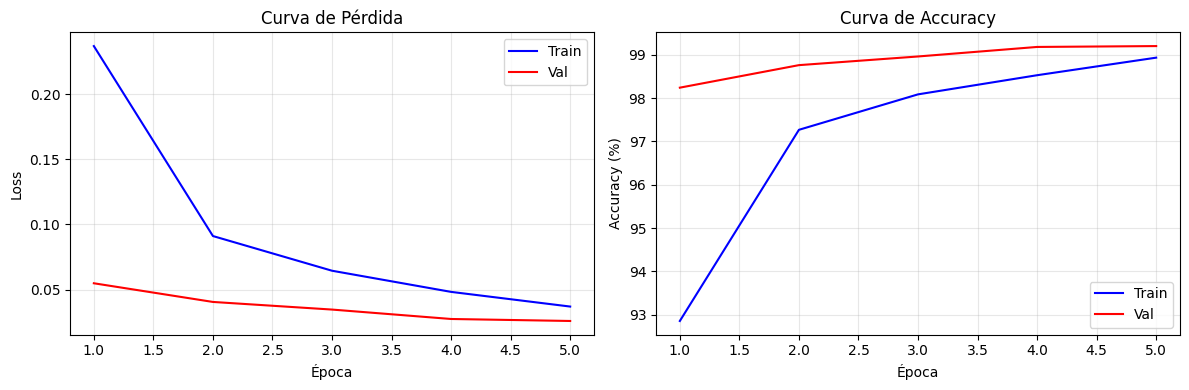

In [41]:
# Visualizar curvas de entrenamiento
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

epochs = range(1, len(history['train_loss']) + 1)

axes[0].plot(epochs, history['train_loss'], 'b-', label='Train')
axes[0].plot(epochs, history['val_loss'], 'r-', label='Val')
axes[0].set_xlabel('Época')
axes[0].set_ylabel('Loss')
axes[0].set_title('Curva de Pérdida')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(epochs, history['train_acc'], 'b-', label='Train')
axes[1].plot(epochs, history['val_acc'], 'r-', label='Val')
axes[1].set_xlabel('Época')
axes[1].set_ylabel('Accuracy (%)')
axes[1].set_title('Curva de Accuracy')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

---

## 10. Guardar y Cargar Modelos

In [42]:
print("="*70)
print("GUARDAR Y CARGAR MODELOS")
print("="*70)

# =====================================================================
# Método 1: Guardar solo pesos (recomendado)
# =====================================================================

print("\n1. Guardar solo pesos (state_dict)")
print("-" * 50)

# Guardar
torch.save(model.state_dict(), 'model_weights.pt')
print("Guardado: torch.save(model.state_dict(), 'model_weights.pt')")

# Cargar
model_new = ConvNet()  # Crear arquitectura
model_new.load_state_dict(torch.load('model_weights.pt'))
model_new.eval()  # Modo evaluación
print("Cargado: model.load_state_dict(torch.load(...))")

GUARDAR Y CARGAR MODELOS

1. Guardar solo pesos (state_dict)
--------------------------------------------------
Guardado: torch.save(model.state_dict(), 'model_weights.pt')
Cargado: model.load_state_dict(torch.load(...))


In [43]:
# =====================================================================
# Método 2: Guardar checkpoint completo (para continuar entrenamiento)
# =====================================================================

print("\n2. Checkpoint completo")
print("-" * 50)

checkpoint = {
    'epoch': CONFIG['epochs'],
    'model_state_dict': model.state_dict(),
    'optimizer_state_dict': optimizer.state_dict(),
    'scheduler_state_dict': scheduler.state_dict(),
    'best_val_acc': best_val_acc,
    'history': history,
    'config': CONFIG
}

torch.save(checkpoint, 'checkpoint.pt')
print("Guardado checkpoint con: model, optimizer, scheduler, history")

# Cargar y continuar entrenamiento
checkpoint = torch.load('checkpoint.pt')
model.load_state_dict(checkpoint['model_state_dict'])
optimizer.load_state_dict(checkpoint['optimizer_state_dict'])
start_epoch = checkpoint['epoch']
print(f"Cargado: continuar desde época {start_epoch}")


2. Checkpoint completo
--------------------------------------------------
Guardado checkpoint con: model, optimizer, scheduler, history
Cargado: continuar desde época 5


In [44]:
# =====================================================================
# Inferencia
# =====================================================================

print("\n3. Inferencia")
print("-" * 50)

def predict(model, image, device):
    """
    Predice la clase de una imagen.
    
    Args:
        model: Modelo entrenado
        image: Tensor (1, 28, 28) o (28, 28)
        device: Dispositivo
    
    Returns:
        predicted_class, confidence
    """
    model.eval()
    
    # Asegurar batch dimension
    if image.dim() == 2:
        image = image.unsqueeze(0).unsqueeze(0)
    elif image.dim() == 3:
        image = image.unsqueeze(0)
    
    image = image.to(device)
    
    with torch.no_grad():
        logits = model(image)
        probs = F.softmax(logits, dim=1)
        confidence, predicted = probs.max(1)
    
    return predicted.item(), confidence.item()

# Test
sample_image = test_data[0][0]
pred_class, confidence = predict(model, sample_image, CONFIG['device'])
print(f"Predicción: {pred_class}, Confianza: {confidence:.2%}")
print(f"Real: {test_data[0][1]}")


3. Inferencia
--------------------------------------------------
Predicción: 7, Confianza: 100.00%
Real: 7


---

## Resumen y Mejores Prácticas

### Checklist para entrenar modelos

1. **Datos**
   - [ ] Dividir en train/val/test
   - [ ] Normalizar inputs
   - [ ] Data augmentation (solo train)
   - [ ] Verificar DataLoader funciona

2. **Modelo**
   - [ ] Verificar shapes con forward pass de prueba
   - [ ] Contar parámetros
   - [ ] Mover a GPU: `model.to(device)`

3. **Entrenamiento**
   - [ ] `model.train()` antes de entrenar
   - [ ] `model.eval()` antes de evaluar
   - [ ] `optimizer.zero_grad()` antes de `backward()`
   - [ ] `torch.no_grad()` para evaluación

4. **Regularización**
   - [ ] Dropout
   - [ ] Weight decay
   - [ ] Early stopping
   - [ ] Learning rate scheduler

5. **Guardado**
   - [ ] Guardar mejor modelo (val acc)
   - [ ] Checkpoints periódicos

### Recursos adicionales

- [Documentación oficial PyTorch](https://pytorch.org/docs/stable/index.html)
- [PyTorch Tutorials](https://pytorch.org/tutorials/)
- [Papers with Code](https://paperswithcode.com/)

---

**Siguiente notebook**: Arquitecturas avanzadas (ResNet, Transformers, etc.)